In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


In [3]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.fc_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        
    def forward(self, x):
        x = self.conv_layer(x)
        x = self.fc_layer(x)
        return x

model = CNN()

In [4]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

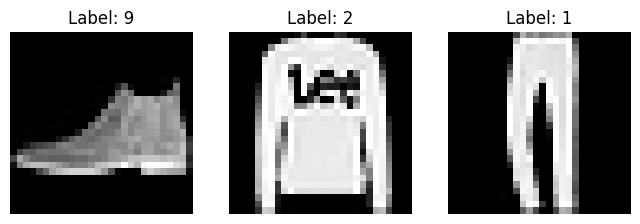

In [ ]:
import matplotlib.pyplot as plt
#Print first three image of the testset
def show_data(dataset):
    figure = plt.figure(figsize=(8, 4))
    for i in range(3):
        img, label = dataset[i]
        img = img.squeeze()
        plt.subplot(1, 3, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')
    plt.show()

show_data(test_dataset)

In [ ]:
# List loss and accuracy values
train_losses = []
train_accuracies = []
num_epochs = 10

for epoch in range(num_epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    
    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}, Training Accuracy: {epoch_accuracy:.2f}%")

Epoch 1, Loss: 0.0258, Training Accuracy: 99.05%
Epoch 2, Loss: 0.0211, Training Accuracy: 99.22%
Epoch 3, Loss: 0.0214, Training Accuracy: 99.25%
Epoch 4, Loss: 0.0191, Training Accuracy: 99.29%
Epoch 5, Loss: 0.0201, Training Accuracy: 99.28%
Epoch 6, Loss: 0.0169, Training Accuracy: 99.40%
Epoch 7, Loss: 0.0197, Training Accuracy: 99.32%
Epoch 8, Loss: 0.0184, Training Accuracy: 99.37%
Epoch 9, Loss: 0.0141, Training Accuracy: 99.49%
Epoch 10, Loss: 0.0158, Training Accuracy: 99.42%


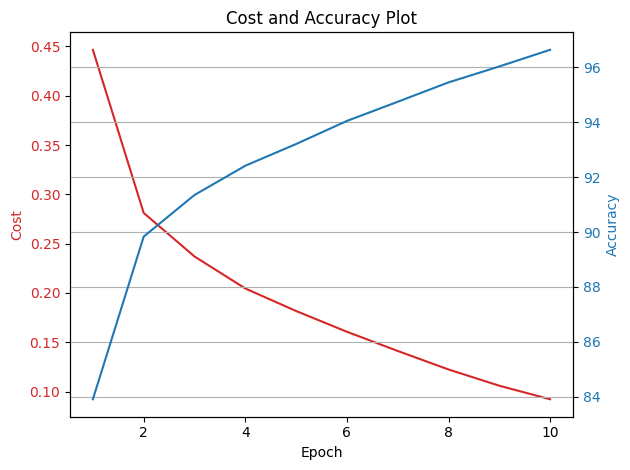

In [ ]:
#Cost Accuracy Plot
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cost', color=color)
ax1.plot(epochs, train_losses, color=color, label='Cost')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Accuracy', color=color)
ax2.plot(epochs, train_accuracies, color=color, label='Accuracy')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Cost and Accuracy Plot')
fig.tight_layout()
plt.grid()
plt.show()

In [ ]:
# Model evaluation score
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

val_accuracy = 100 * correct / total
print(f"Validation Accuracy: {val_accuracy:.2f}%")


Validation Accuracy: 91.58%
